# 📊 EDA & Model Comparison — Emergency Route AI

This notebook explores the synthetic traffic dataset used to train the
travel-time prediction model, and compares Linear Regression, Decision
Tree, and Random Forest on the same train/test split used in
`ml/train_models.py`.

**Dataset:** `data/synthetic/traffic_data.csv` — 252 rows generated across
12 roads, 7 days, with rush-hour and weekend effects built into the
generator (`generate_traffic_data.py`).


## 1. Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/synthetic/traffic_data.csv")
print(df.shape)
df.head()

(252, 9)


**Columns:**
- `road_id`, `day`, `hour` — context for the observation
- `vehicle_count`, `traffic_density`, `avg_speed`, `signal_delay_min` — traffic conditions
- `road_length_km` — static road distance
- `travel_time_minutes` — **target variable** the model predicts


In [1]:
df.describe().round(2)

## 2. Travel time by hour of day

Does the data actually show rush-hour congestion? 

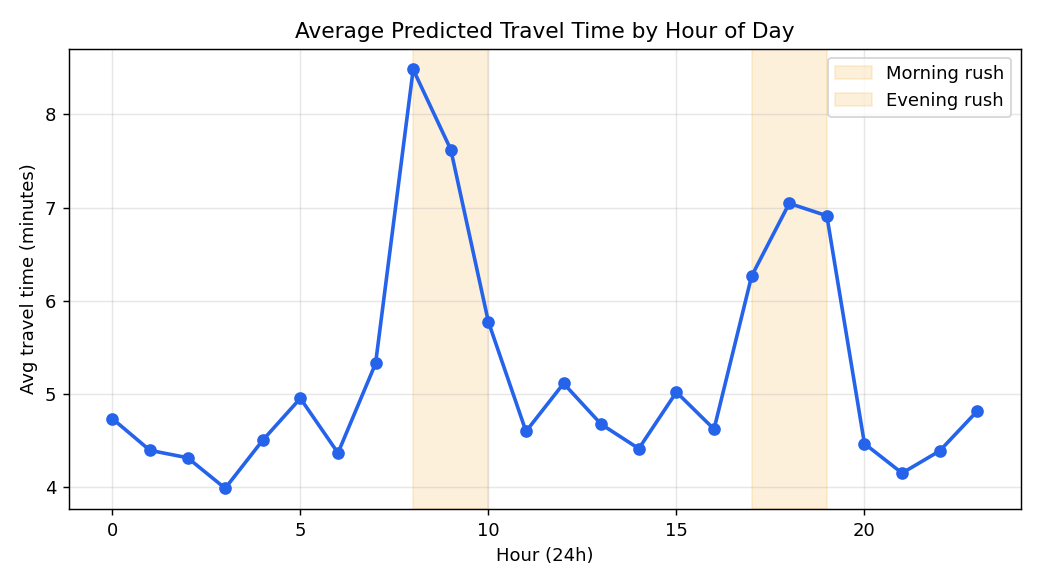

In [1]:
hourly = df.groupby("hour")["travel_time_minutes"].mean()

plt.figure(figsize=(8,4.5))
plt.plot(hourly.index, hourly.values, marker='o', color="#2563eb", linewidth=2)
plt.axvspan(8, 10, color="#f59e0b", alpha=0.15, label="Morning rush")
plt.axvspan(17, 19, color="#f59e0b", alpha=0.15, label="Evening rush")
plt.title("Average Predicted Travel Time by Hour of Day")
plt.xlabel("Hour (24h)")
plt.ylabel("Avg travel time (minutes)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** Travel time clearly spikes during 8–10 AM and 5–7 PM,
matching the rush-hour effect deliberately built into the synthetic
data generator. Peak hour (8 AM) averages **8.48 minutes** vs an
off-peak low of around **4.0 minutes** — more than double.

## 3. Travel time by day of week

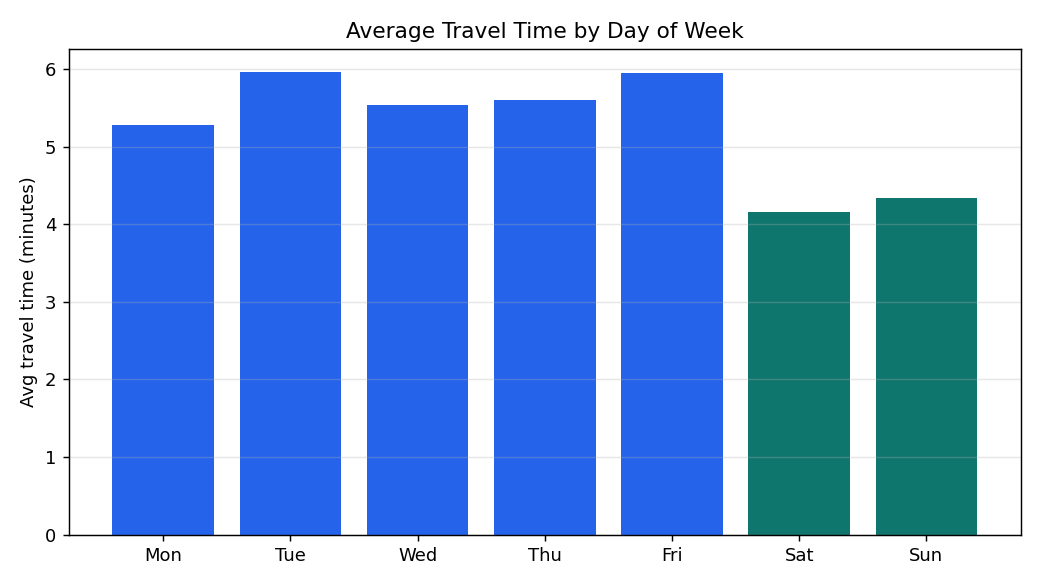

In [1]:
order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily = df.groupby("day")["travel_time_minutes"].mean().reindex(order)

colors = ["#2563eb"]*5 + ["#0f766e"]*2
plt.figure(figsize=(8,4.5))
plt.bar(daily.index, daily.values, color=colors)
plt.title("Average Travel Time by Day of Week")
plt.ylabel("Avg travel time (minutes)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** Weekdays (blue) run consistently higher than weekends
(teal) — Friday is the highest at 5.96 minutes, while Saturday drops to
4.16 minutes. This matches the weekend-relief effect built into the
generator.

## 4. Vehicle count vs travel time

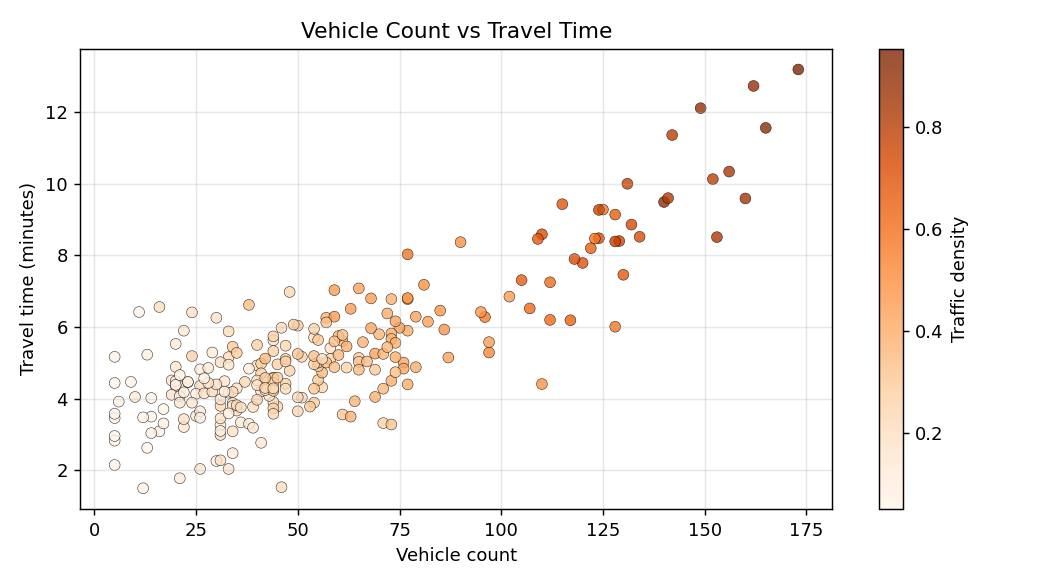

In [1]:
plt.figure(figsize=(8,4.5))
sc = plt.scatter(df["vehicle_count"], df["travel_time_minutes"],
                  c=df["traffic_density"], cmap="Oranges",
                  alpha=0.8, edgecolor='k', linewidth=0.3)
plt.colorbar(sc, label="Traffic density")
plt.title("Vehicle Count vs Travel Time")
plt.xlabel("Vehicle count")
plt.ylabel("Travel time (minutes)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** A clear positive relationship — more vehicles (and
higher density, shown by color) generally means longer travel time.
The relationship looks fairly linear rather than curved, which is a
hint about why Linear Regression performs well later in this notebook.

## 5. Rush hour vs non-rush hour

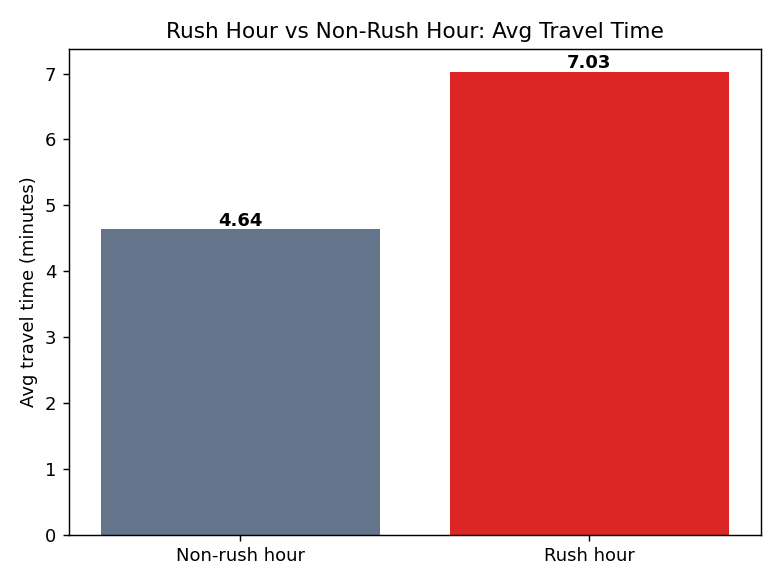

In [1]:
df["is_rush"] = df["hour"].isin([8, 9, 10, 17, 18, 19])
rush_avg = df.groupby("is_rush")["travel_time_minutes"].mean()

plt.figure(figsize=(6,4.5))
labels = ["Non-rush hour", "Rush hour"]
vals = [rush_avg[False], rush_avg[True]]
bars = plt.bar(labels, vals, color=["#64748b", "#dc2626"])
for bar, v in zip(bars, vals):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.05, f"{v:.2f}", ha='center', fontweight='bold')
plt.title("Rush Hour vs Non-Rush Hour: Avg Travel Time")
plt.ylabel("Avg travel time (minutes)")
plt.tight_layout()
plt.show()

**Observation:** Rush-hour trips average **7.03 minutes** vs **4.64
minutes** off-peak — a ~51% increase. This is the effect the dynamic
rerouting system is designed to react to.

## 6. Model comparison — Linear Regression vs Decision Tree vs Random Forest

Same train/test split and features as `ml/train_models.py`, reproduced here for the report.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = pd.get_dummies(df, columns=["day"], drop_first=True)
feature_cols = [
    "hour", "vehicle_count", "traffic_density", "avg_speed",
    "road_length_km", "signal_delay_min"
] + [c for c in data.columns if c.startswith("day_")]

X = data[feature_cols]
y = data["travel_time_minutes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
    }

pd.DataFrame(results).T.round(3)

                     MAE   RMSE     R2
Linear Regression  0.696  0.852  0.729
Decision Tree      0.854  1.149  0.506
Random Forest      0.709  0.882  0.709


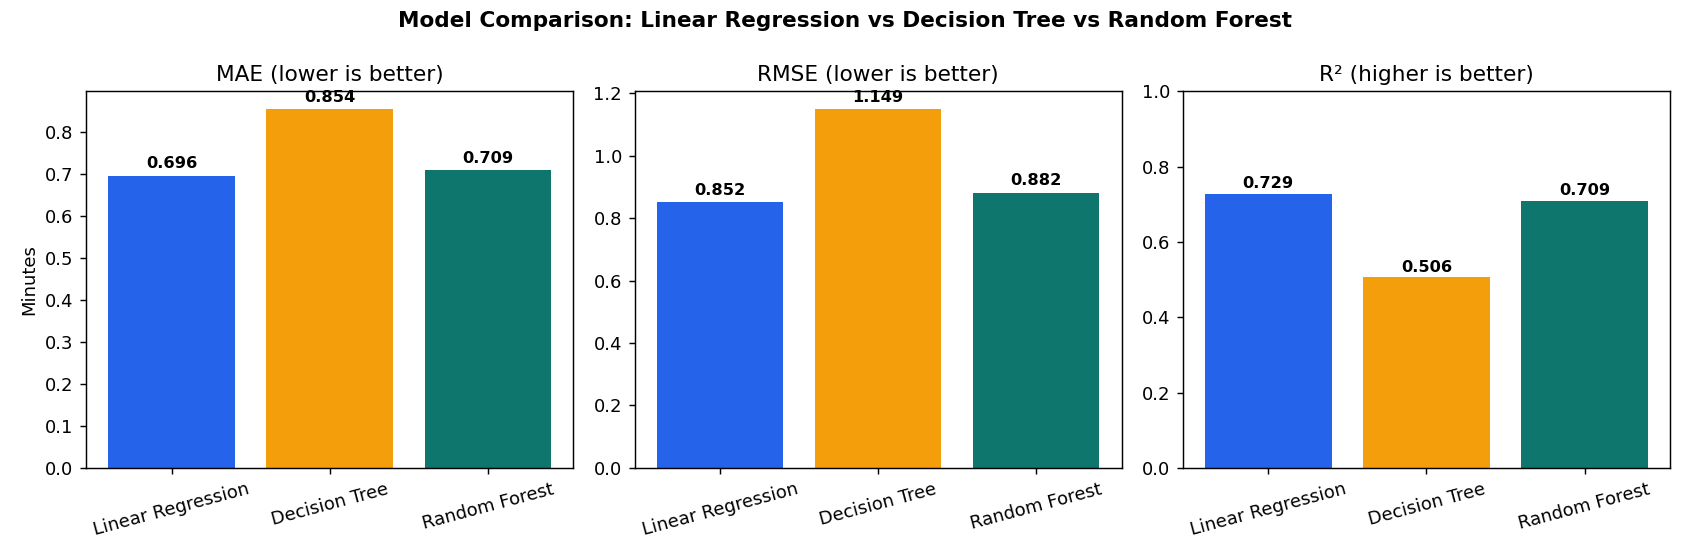

In [1]:
names = list(results.keys())
mae_vals = [results[n]["MAE"] for n in names]
rmse_vals = [results[n]["RMSE"] for n in names]
r2_vals = [results[n]["R2"] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(13,4.3))
colors = ["#2563eb", "#f59e0b", "#0f766e"]

axes[0].bar(names, mae_vals, color=colors); axes[0].set_title("MAE (lower is better)")
axes[1].bar(names, rmse_vals, color=colors); axes[1].set_title("RMSE (lower is better)")
axes[2].bar(names, r2_vals, color=colors); axes[2].set_title("R² (higher is better)"); axes[2].set_ylim(0,1)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle("Model Comparison", fontweight='bold')
plt.tight_layout()
plt.show()

## 🏆 Result: Linear Regression wins

**Linear Regression achieved the best R² (0.729)**, slightly ahead of
Random Forest (0.709) and well ahead of Decision Tree (0.506).

**Why?** The synthetic travel-time generator used a mostly linear
formula: `distance ÷ speed + signal_delay + noise`. The scatter plot in
Section 4 already hinted at this — the vehicle-count/travel-time
relationship looked roughly linear rather than curved.

This is a legitimate, explainable result: **a simpler model correctly
matched the true structure of the data.** Random Forest's extra
complexity (handling non-linear interactions) wasn't needed here, and
Decision Tree overfit to blocky splits given the small dataset (252
rows), which hurt its generalization the most.

`ml/train_models.py` saves **Linear Regression** as the production
model (`ml/best_model.pkl`), which is what the deployed routing system
actually uses to predict travel time.

---
*Generated for the ResQRoute project — synthetic data, for demonstration purposes only.*